# Monte Carlo Dropout

In this model, the network ends with **2 outputs**:
$$[\mu(x), \log(\sigma^2(x))]$$

* **$\mu(x)$** $\rightarrow$ Mean prediction (expected value).
* **$\log(\sigma^2(x))$** $\rightarrow$ Logarithm of the variance (data uncertainty).

The loss function used is the **Gaussian Negative Log-Likelihood (NLL)**:
$$\mathcal{L} = \frac{1}{2}\left[\log(\sigma^2(x)) + \frac{(y - \mu(x))^2}{\sigma^2(x)}\right]$$

This way, the network learns not only to predict the value but also its **confidence level** (noise or variance per point).



**Monte Carlo Dropout (MC Dropout)** keeps *dropout* active during prediction (`training=True`), generating multiple random model outputs.
The dispersion among these predictions allows for estimating **epistemic uncertainty** (model-related), while the `log(σ²)` output provides the **aleatoric uncertainty** (data-related).



Finally, the **total variance** is obtained by combining both:
$$\text{Var}_{\text{total}}(y) = \underbrace{\text{E}[\sigma^2(x)]}_{\text{aleatoric}} + \underbrace{\text{Var}[\mu(x)]}_{\text{epistemic}}$$

In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

# seed
SEED = 7
np.random.seed(SEED)
torch.manual_seed(SEED)

print("PyTorch version:", torch.__version__)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

PyTorch version: 2.10.0+cu128
Device: cpu


In [2]:
def create_toy_regression_dataset(
    xmin=-10.0, xmax=10.0, n_gt=1000, n_trn=128, n_tst=200, noise_std=0.2
):
    """Generate synthetic data from a sine function with Gaussian noise added to the training set.

    Returns: (x_gt, y_gt, x_trn, y_trn, x_tst, y_tst)
    """
    # Ground truth curve
    x_gt = np.linspace(xmin, xmax, n_gt, dtype=np.float64)
    y_gt = np.sin(0.3 * x_gt) * 3.0  # amplitude 3, moderate frequency

    # Training set
    x_trn = np.random.uniform(xmin, xmax, size=n_trn).astype(np.float64)
    y_trn = np.sin(0.3 * x_trn) * 3.0 + np.random.normal(0.0, noise_std, size=n_trn)

    # Test/evaluation set
    x_tst = np.linspace(xmin, xmax, n_tst, dtype=np.float64)
    y_tst = np.sin(0.3 * x_tst) * 3.0

    return x_gt, y_gt, x_trn, y_trn, x_tst, y_tst


def plot_regression_model_analysis(
    gt, trn, pred, xlim=None, ylim=None, title="MC Dropout Regression (PyTorch)"
):
    """Plots:
    - training points
    - ground truth curve
    - predicted mean + band [mean ± 2*std]
    """
    x_gt, y_gt = gt
    x_trn, y_trn = trn
    x_pred, y_mean, y_std = pred

    plt.figure(figsize=(8, 4.5))
    # Training data points
    plt.scatter(x_trn, y_trn, s=16, alpha=0.6, label="Train")
    # Ground truth curve
    plt.plot(x_gt, y_gt, linewidth=2, label="GT")
    # Uncertainty band
    upper = y_mean + 2.0 * y_std
    lower = y_mean - 2.0 * y_std
    plt.fill_between(x_pred, lower, upper, alpha=0.25, label="±2σ")
    # Predicted mean
    plt.plot(x_pred, y_mean, linewidth=2, label="Pred mean")

    if xlim is not None:
        plt.xlim(*xlim)
    if ylim is not None:
        plt.ylim(*ylim)

    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.grid(True)
    plt.show()

In [3]:
def gaussian_nll(y_true: torch.Tensor, y_pred: torch.Tensor) -> torch.Tensor:
    """Gaussian negative log likelihood con log-var como salida.

    y_true: [N, 1] o [N]
    y_pred: [N, 2] -> [:,0]=mu, [:,1]=log_var
    """
    y_true = y_true.reshape(-1)  # [N]

    mu = y_pred[:, 0]  # [N]

    log_var = y_pred[:, 1]  # [N]

    loss = (log_var + (y_true - mu).pow(2) / torch.exp(log_var)) / 2.0

    return loss.mean()


We define a specific architecture to implement **Monte Carlo Dropout**. 



**Key points about this architecture:**
* the choice of two hidden layers with 10 neurons each is somewhat arbitrary. It is kept simple to clearly demonstrate the transition between aleatoric and epistemic uncertainty without unnecessary computational overhead.
* **Dual Output (Must be 2):** Unlike standard regression, the final layer has **2 neurons**. This is crucial because the model must output both the predicted mean $\mu(x)$ and the log-variance $\log(\sigma^2(x))$.
* **Activation Functions:** We use a combination of `ReLU` and `Tanh` to introduce non-linearity, followed by a `Dropout` layer (p=0.5) before the final output.
* **MC Dropout Logic:** By keeping the `Dropout` layer active during inference, we can sample multiple different "versions" of the network to quantify model uncertainty.


In [4]:
def define(seed: int | None = None) -> nn.Module:
    if seed is not None:
        torch.manual_seed(seed)
        np.random.seed(seed)

    model = nn.Sequential(
        nn.Linear(1, 10),
        nn.ReLU(),
        nn.Linear(10, 10),
        nn.Tanh(),
        nn.Dropout(p=0.5),
        nn.Linear(10, 2),  # output: mu, log_var
    )
    return model

In [5]:
def train(
    x,
    y,
    model,
    epochs: int = 100,
    batch_size: int = 32,
    lr: float = 1e-3,
    device: str | None = None,
):
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    model = model.to(device)

    x_t = torch.as_tensor(x, dtype=torch.float32)
    y_t = torch.as_tensor(y, dtype=torch.float32)

    ds = TensorDataset(x_t, y_t)  # x: [N,1], y: [N,1]
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True)

    optim = torch.optim.Adam(model.parameters(), lr=lr)

    model.train()
    for _ in range(epochs):
        for xb, yb in dl:
            xb = xb.to(device)
            yb = yb.to(device)

            pred = model(xb)  # [B,2]
            loss = gaussian_nll(yb, pred)

            optim.zero_grad()
            loss.backward()
            optim.step()

    return model

In [6]:
def predict(model: nn.Module, x, samples: int = 20, device: str | None = None):
    """MC Dropout prediction.

    Returns:

        y_mean (np.ndarray [N]), y_std (np.ndarray [N])
    """
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    x_t = torch.as_tensor(x, dtype=torch.float32, device=device)

    mu_list = []
    logvar_list = []

    # Activamos dropout durante la inferencia forzando train(), pero sin gradientes
    model.train()
    with torch.no_grad():
        for _ in range(samples):
            y_pred = model(x_t)  # [N,2]
            mu = y_pred[:, 0]
            log_var = y_pred[:, 1]
            mu_list.append(mu.cpu().numpy())
            logvar_list.append(log_var.cpu().numpy())

    mu_arr = np.stack(mu_list, axis=0)  # [S, N]
    logvar_arr = np.stack(logvar_list, axis=0)  # [S, N]
    var_arr = np.exp(logvar_arr)  # [S, N]

    y_mean = np.mean(mu_arr, axis=0)  # [N]
    # Var(Y) = E[var] + Var(mu)
    y_variance = np.mean(var_arr + mu_arr**2, axis=0) - y_mean**2
    y_std = np.sqrt(y_variance)
    return y_mean, y_std

### Main execution

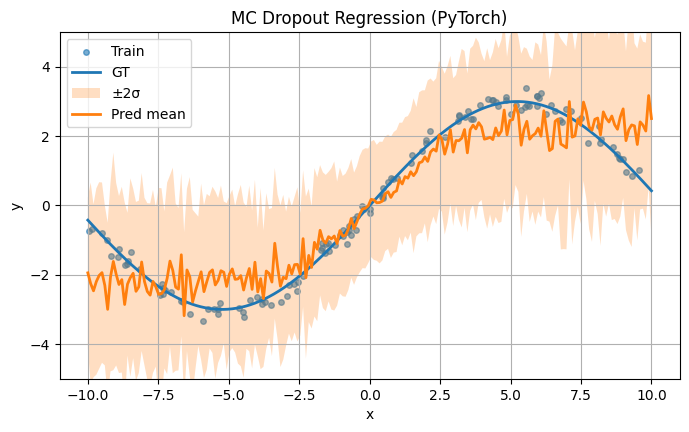

In [7]:
xmin, xmax = -10.0, 10.0

data = create_toy_regression_dataset(xmin=xmin, xmax=xmax, noise_std=0.2)
x_gt, y_gt, x_trn, y_trn, x_tst, y_tst = data

model = define(seed=SEED)
model = train(x_trn[:, np.newaxis], y_trn[:, np.newaxis], model, epochs=100)

yhat_mean, yhat_std = predict(model, x_tst[:, np.newaxis], samples=5)

plot_regression_model_analysis(
    gt=(x_gt, y_gt),
    trn=(x_trn, y_trn),
    pred=(x_tst, yhat_mean, yhat_std),
    xlim=(-11, 11),
    ylim=(-5, 5),
    title="MC Dropout Regression (PyTorch)",
)